# Random Forest Classifier on the Augmented data set

## Imports Paths and Settings

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [2]:
DATASET_PATH = r"C:\Users\wldky\OneDrive - Montana Tech\Spring-2026\CSCI 447\ML Project\dataset\processed\dataset.npz"
OUTPUT_DIR   = r"C:\Users\wldky\OneDrive - Montana Tech\Spring-2026\CSCI 447\ML Project\dataset\results"

In [3]:
PCA_COMPONENTS = 150
N_ESTIMATORS   = 100
MAX_DEPTH      = 20
RANDOM_SEED    = 42

## Functions

In [4]:
def load_data(path):
    """Load the augmented dataset."""
    print("Loading augmented dataset...")
    data = np.load(path)
 
    X_train = np.concatenate([data['X_train'], data['X_val']])
    y_train = np.concatenate([data['y_train'], data['y_val']])
    X_test  = data['X_test']
    y_test  = data['y_test']
 
    print(f"  Training samples: {len(X_train)}")
    print(f"  Test samples:     {len(X_test)}")
    print(f"  Features:         {X_train.shape[1]:,}\n")
 
    return X_train, X_test, y_train, y_test

In [5]:
def plot_confusion_matrix(y_true, y_pred, filename):
    """Plot and save a confusion matrix."""
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=[f'PSA {i}' for i in range(1, 11)],
        yticklabels=[f'PSA {i}' for i in range(1, 11)]
    )
    plt.title(f'PCA + Random Forest Classifier\nAugmented Dataset (PCA={PCA_COMPONENTS}, trees={N_ESTIMATORS})')
    plt.ylabel('True Grade')
    plt.xlabel('Predicted Grade')
    plt.tight_layout()
    save_path = os.path.join(OUTPUT_DIR, filename)
    plt.savefig(save_path)
    plt.show()
    print(f"Confusion matrix saved to: {save_path}")

In [6]:
def plot_accuracy_per_grade(y_true, y_pred, filename):
    """
    Bar plot showing exact accuracy and within-1-grade accuracy
    broken down per PSA grade so you can see which grades the
    model struggles with most.
    """
    grades     = list(range(1, 11))
    exact_acc  = []
    within_acc = []
 
    for grade in grades:
        mask       = y_true == grade
        if mask.sum() == 0:
            exact_acc.append(0)
            within_acc.append(0)
            continue
        grade_true  = y_true[mask]
        grade_pred  = y_pred[mask]
        exact_acc.append(accuracy_score(grade_true, grade_pred))
        within_acc.append(np.mean(np.abs(grade_true - grade_pred) <= 1))
 
    x     = np.arange(len(grades))
    width = 0.35
 
    fig, ax = plt.subplots(figsize=(12, 6))
    bars1 = ax.bar(x - width/2, [a*100 for a in exact_acc],  width, label='Exact Accuracy',  color='steelblue')
    bars2 = ax.bar(x + width/2, [a*100 for a in within_acc], width, label='Within 1 Grade', color='lightgreen')
 
    ax.set_ylabel('Accuracy (%)')
    ax.set_title('PCA + Random Forest: Accuracy per PSA Grade\n(Augmented Dataset)')
    ax.set_xticks(x)
    ax.set_xticklabels([f'PSA {g}' for g in grades])
    ax.legend()
    ax.set_ylim(0, 110)
 
    # Add value labels on bars
    for bar in bars1:
        height = bar.get_height()
        ax.annotate(f'{height:.1f}%',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', fontsize=8)
    for bar in bars2:
        height = bar.get_height()
        ax.annotate(f'{height:.1f}%',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', fontsize=8)
 
    plt.tight_layout()
    save_path = os.path.join(OUTPUT_DIR, filename)
    plt.savefig(save_path)
    plt.show()
    print(f"Bar plot saved to: {save_path}")

## Main Function

Loading augmented dataset...
  Training samples: 6487
  Test samples:     1145
  Features:         150,528

Training PCA + Random Forest Classifier...
  PCA components: 150
  Trees:          100
  Max depth:      20



[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    1.5s finished



Training complete!



[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    0.0s finished


Results on Test Set
  Exact accuracy:  50.9%  (baseline was 51.0%)
  Within 1 grade:  76.9%  (baseline was 76.3%)

Classification Report:
              precision    recall  f1-score   support

       PSA 1       0.00      0.00      0.00         7
       PSA 2       1.00      0.25      0.40         4
       PSA 3       1.00      0.29      0.44        56
       PSA 4       0.94      0.28      0.43        61
       PSA 5       0.74      0.27      0.39       131
       PSA 6       0.68      0.21      0.32        73
       PSA 7       0.46      0.66      0.54       264
       PSA 8       0.43      0.68      0.53       284
       PSA 9       0.60      0.57      0.58       218
      PSA 10       0.90      0.19      0.32        47

    accuracy                           0.51      1145
   macro avg       0.68      0.34      0.40      1145
weighted avg       0.59      0.51      0.49      1145



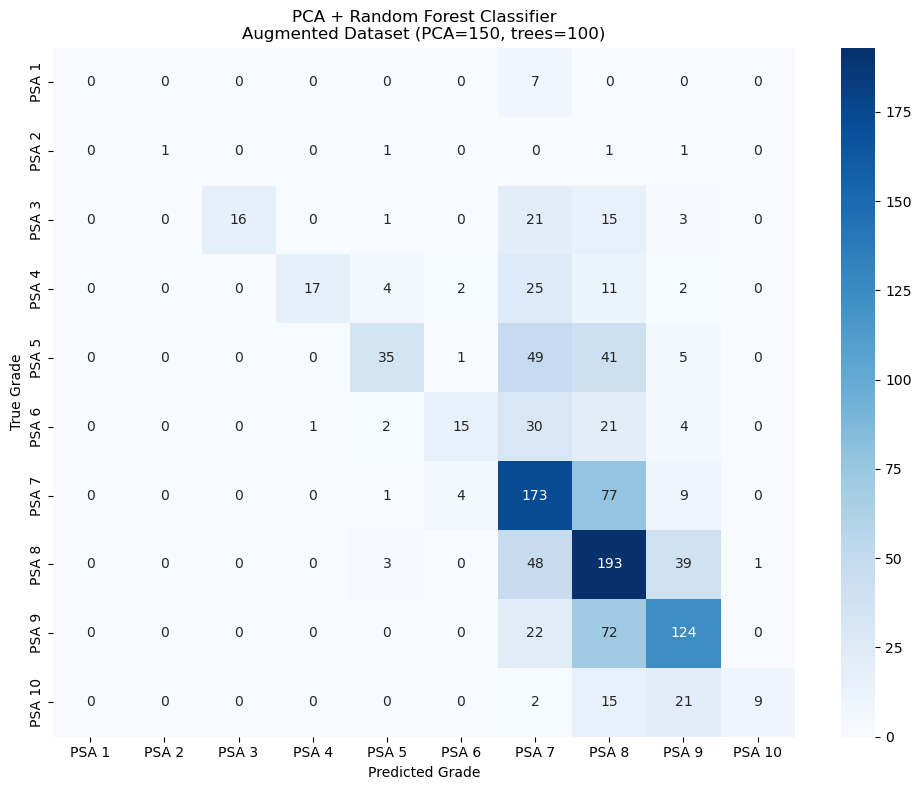

Confusion matrix saved to: C:\Users\wldky\OneDrive - Montana Tech\Spring-2026\CSCI 447\ML Project\dataset\results\rf_augmented_confusion.png


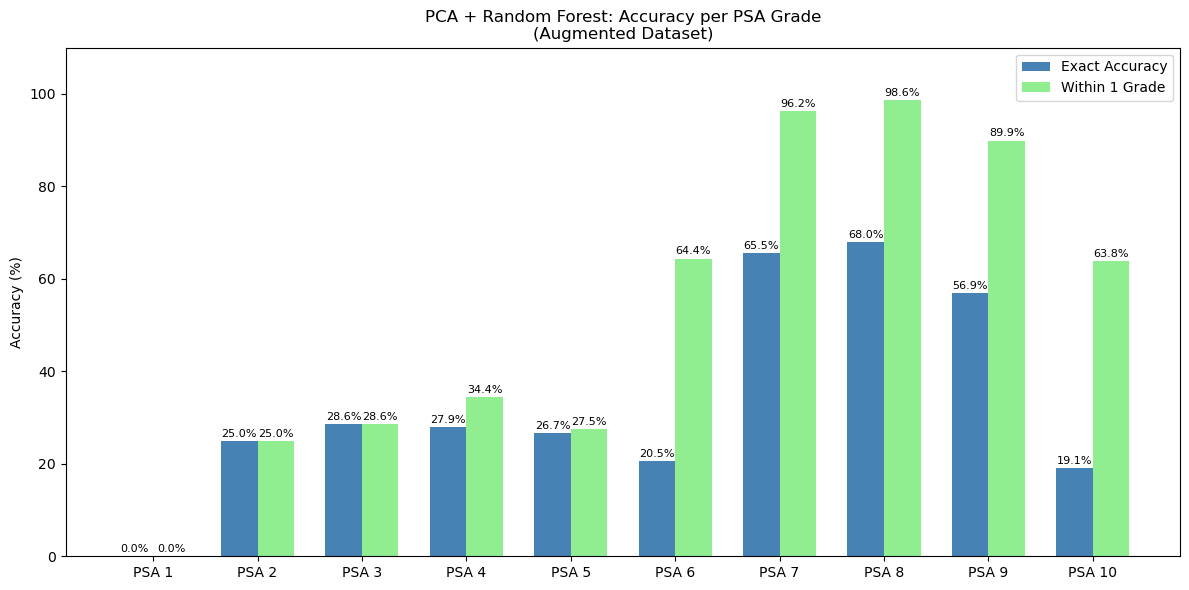

Bar plot saved to: C:\Users\wldky\OneDrive - Montana Tech\Spring-2026\CSCI 447\ML Project\dataset\results\rf_augmented_per_grade.png

Results saved to: C:\Users\wldky\OneDrive - Montana Tech\Spring-2026\CSCI 447\ML Project\dataset\results\rf_augmented_results.txt

All done!


In [7]:

os.makedirs(OUTPUT_DIR, exist_ok=True)

X_train, X_test, y_train, y_test = load_data(DATASET_PATH)

# Build and train model
print(f"{'='*50}")
print(f"Training PCA + Random Forest Classifier...")
print(f"  PCA components: {PCA_COMPONENTS}")
print(f"  Trees:          {N_ESTIMATORS}")
print(f"  Max depth:      {MAX_DEPTH}")
print(f"{'='*50}\n")

model = Pipeline([
    ('pca', PCA(n_components=PCA_COMPONENTS, random_state=RANDOM_SEED)),
    ('rf',  RandomForestClassifier(
                n_estimators=N_ESTIMATORS,
                max_depth=MAX_DEPTH,
                random_state=RANDOM_SEED,
                n_jobs=-1,
                verbose=1
            ))
])

model.fit(X_train, y_train)
print("\nTraining complete!\n")

# Evaluate
preds      = model.predict(X_test)
accuracy   = accuracy_score(y_test, preds)
within_one = np.mean(np.abs(y_test - preds) <= 1)

print(f"{'='*50}")
print(f"Results on Test Set")
print(f"{'='*50}")
print(f"  Exact accuracy:  {accuracy*100:.1f}%  (baseline was 51.0%)")
print(f"  Within 1 grade:  {within_one*100:.1f}%  (baseline was 76.3%)")
print(f"\nClassification Report:")
print(classification_report(
    y_test, preds,
    target_names=[f'PSA {i}' for i in range(1, 11)],
    zero_division=0
))

# Plots
plot_confusion_matrix(y_test, preds, "rf_augmented_confusion.png")
plot_accuracy_per_grade(y_test, preds, "rf_augmented_per_grade.png")

# Save results
results_path = os.path.join(OUTPUT_DIR, 'rf_augmented_results.txt')
with open(results_path, 'w', encoding='utf-8') as f:
    f.write(f"PCA + Random Forest Classifier Results (Augmented Dataset)\n{'='*60}\n\n")
    f.write(f"Parameters:\n")
    f.write(f"  PCA components: {PCA_COMPONENTS}\n")
    f.write(f"  Trees:          {N_ESTIMATORS}\n")
    f.write(f"  Max depth:      {MAX_DEPTH}\n\n")
    f.write(f"Results:\n")
    f.write(f"  Exact accuracy:  {accuracy*100:.1f}%\n")
    f.write(f"  Within 1 grade:  {within_one*100:.1f}%\n\n")
    f.write(f"Classification Report:\n")
    f.write(classification_report(
        y_test, preds,
        target_names=[f'PSA {i}' for i in range(1, 11)],
        zero_division=0
    ))
print(f"\nResults saved to: {results_path}")
print("\nAll done!")

## Saving Model

In [9]:
import joblib
import json
import os

MODEL_DIR     = r"C:\Users\wldky\OneDrive - Montana Tech\Spring-2026\CSCI 447\ML Project\model"
MODEL_PATH    = os.path.join(MODEL_DIR, "rf_model.pkl")
METADATA_PATH = os.path.join(MODEL_DIR, "model_metadata.json")

os.makedirs(MODEL_DIR, exist_ok=True)

# Save model
joblib.dump(model, MODEL_PATH)
print(f"Model saved to: {MODEL_PATH}")

# Save metadata
metadata = {
    'image_size':     (224, 224),
    'pca_components': 150,
    'n_estimators':   100,
    'max_depth':      20,
    'grades':         list(range(1, 11)),
    'accuracy':       float(accuracy),
    'within_one':     float(within_one)
}
with open(METADATA_PATH, 'w') as f:
    json.dump(metadata, f, indent=2)
print(f"Metadata saved to: {METADATA_PATH}")

Model saved to: C:\Users\wldky\OneDrive - Montana Tech\Spring-2026\CSCI 447\ML Project\model\rf_model.pkl
Metadata saved to: C:\Users\wldky\OneDrive - Montana Tech\Spring-2026\CSCI 447\ML Project\model\model_metadata.json
